# CLASSIFYING FASHION IMAGES USING CNNs

## PROBLEM STATEMENT

- **Fashion-MNIST** is a dataset comprising several images divided into the following 10 classes:
    - T-shirt/top
    - Trouser
    - Pullover
    - Dress
    - Coat
    - Sandal
    - Shirt
    - Sneaker
    - Bag
    - Ankle boot

- The dataset was created as a more challenging replacement benchmark for the traditional MNIST dataset of handwritten digits.
- **Fashion-MNIST** is widely used for machine learning and computer vision applications, especially for benchmarking image classification algorithms.
- The dataset consists of 70,000 28x28 grayscale images, with 7,000 images of each class.
- Images have a resolution of 28x28 pixels
- Data Source: [GitHub - zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist)


# STEP 1: IMPORT LIBRARIES/DATASETS

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Fashion-MNIST dataset, split into training and testing sets
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [3]:
train_images.shape

(60000, 28, 28)

The training dataset consists of 60,000 grayscale images, each 28x28 pixels.

In [4]:
test_images.shape

(10000, 28, 28)

The test dataset contains 10,000 grayscale images, each with a resolution of 28x28 pixels.

In [5]:
train_labels.shape

(60000,)

The shape of train_labels indicates that there are 60,000 labels in the training dataset, with each label corresponding to one of the training images.

In [6]:
test_labels.shape

(10000,)

The shape of test_labels indicates that there are 10,000 labels in the test dataset, with each label corresponding to one of the test images.

# STEP 2: VISUALISE DATA

In [7]:
# Define the label names for the Fashion-MNIST dataset
label_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

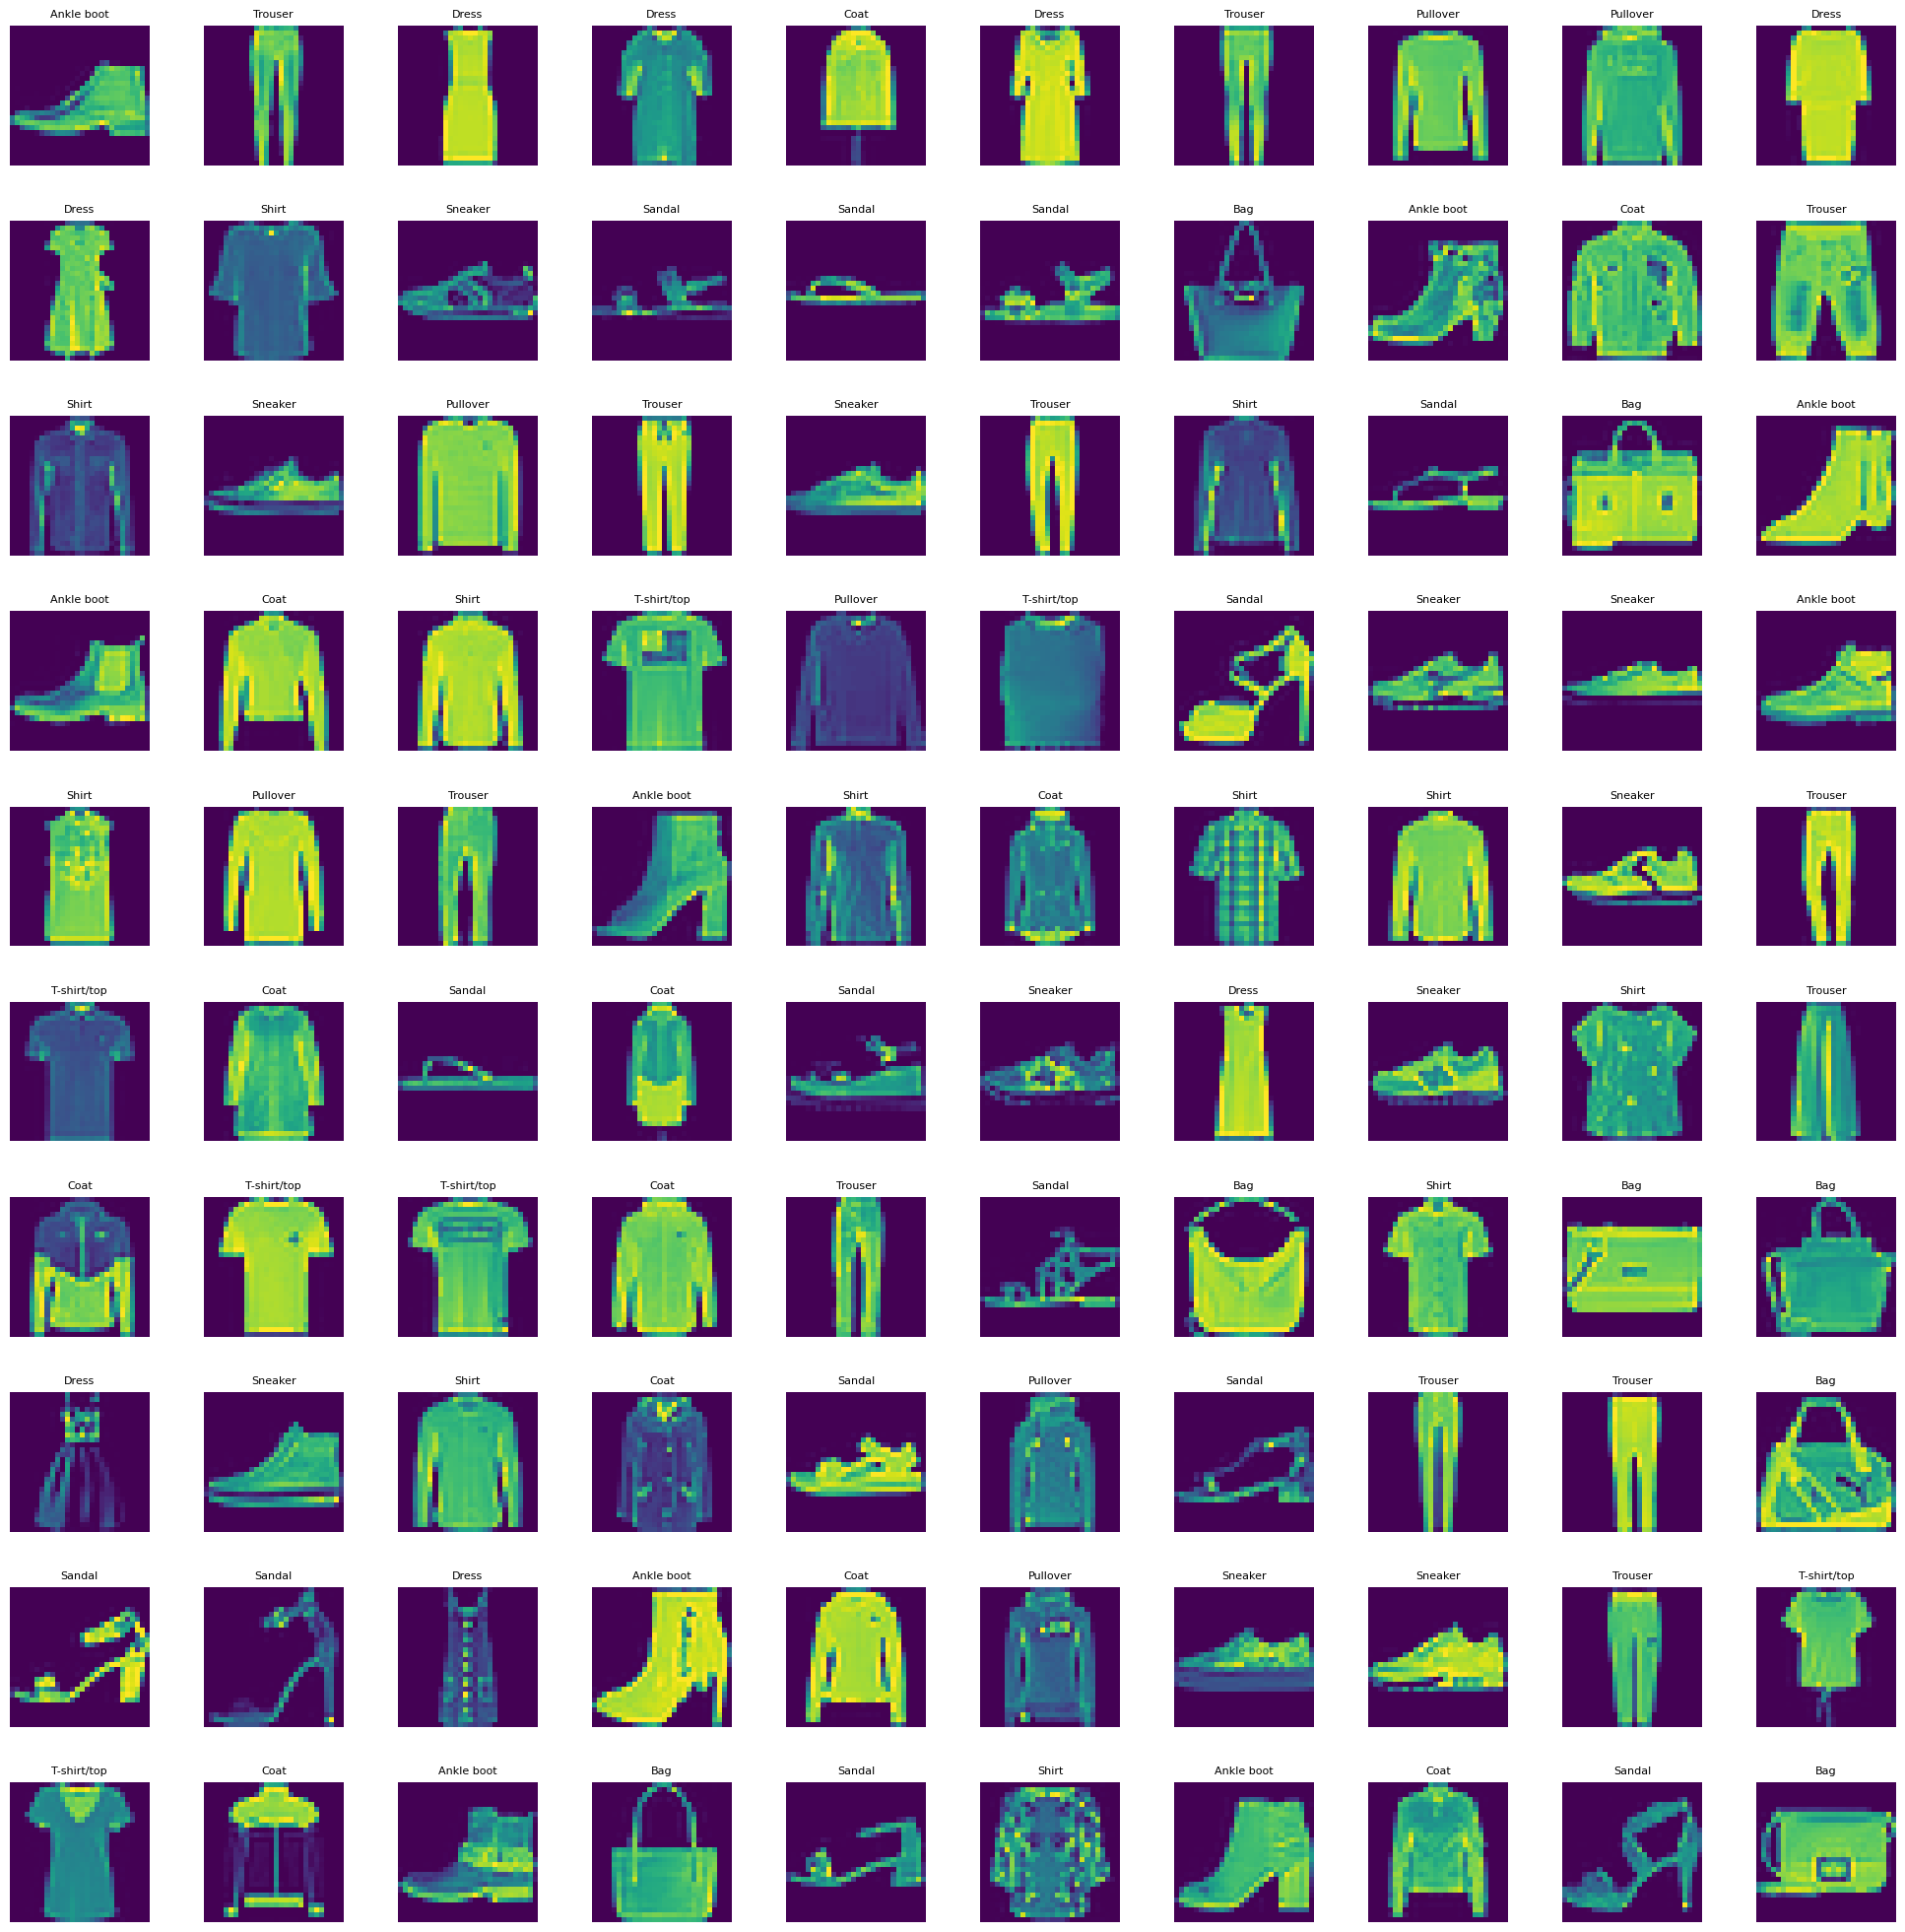

In [8]:
# Define the grid size for display
W_grid = 10
L_grid = 10

# Create a grid of subplots
fig, axes = plt.subplots(L_grid, W_grid, figsize=(25,25))
axes = axes.ravel() # Flatten the 10x10 grid into 100 elements to easily loop through


# Get the total number of training images
n_training = len(train_images)

# Loop over the grid and randomly select images to display
for i in np.arange(0, L_grid*W_grid):
    index = np.random.randint(0, n_training) # Randomly pick an index from the training set
    axes[i].imshow(train_images[index]) # Display image at that index
    axes[i].set_title(label_names[train_labels[index]], fontsize=8) # Set the title to the corresponding label name
    axes[i].axis('off') # Turn off the axis

    
# Adjust the spacing between the plots
plt.subplots_adjust(hspace=0.4)

In [9]:
# Find unique labels in the training dataset

unique_labels = np.unique(train_labels)

unique_labels

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [10]:
# The number of distinct labels is the size of the unique_labels array
num_distinct_labels = unique_labels.size

print(f"Number of distinct labels: {num_distinct_labels}")

Number of distinct labels: 10


# STEP 3: DATA PREPARATION

In [11]:
# Convert the image pixel values to float32 for both training and testing sets
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

In [12]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [13]:
# Convert class vectors (integers) to binary class matrices for the training data
train_labels = tf.keras.utils.to_categorical(train_labels, num_distinct_labels)

# Display the new binary matrix representation of the train labels
train_labels

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [14]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [15]:
# Convert class vectors (integers) to binary class matrics for testing data
test_labels = tf.keras.utils.to_categorical(test_labels, num_distinct_labels)

# Display the new binary matrix representation of the test labels
test_labels

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [16]:
# Normalise the image pixel values from [0, 255] to [0, 1]

train_images, test_images = train_images / 255.0, test_images / 255.0

In [17]:
train_images.shape

(60000, 28, 28)

In [18]:
# Extend the input featue shape to include the channel dimension for CNN input

input_features_shape = train_images.shape[1:] + (1,)

input_features_shape

(28, 28, 1)

The output (28, 28, 1) indicates that each image has a height of 28 pixels, a width of 28 pixels, and 1 channel (since the images are grayscale). This extra dimension is necessary because the convolutional layers in a CNN expect a 3-dimensional input (height, width, channels). If the images were colored (RGB), the channel dimension would be 3.

# STEP 4: TRAIN THE MODEL

In [19]:
# Import the Sequential model API from Keras
from keras.models import Sequential

# Import various layers that will be used to construct the CNN
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

# Set seed for reproducibility
tf.random.set_seed(42)


In [20]:
# Initialise the Sequential model
cnn_model = Sequential()

# Add the first convolutional layers with 64 filters, a 3x3 kernel, and ReLU activation function
cnn_model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=input_features_shape))

# Add another convolutional layer with 64 filters, a 3x3 kernel, and ReLU activation function
cnn_model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))

# Add a max pooling layer with a 2x2 window to reduce to spatial dimensions
cnn_model.add(MaxPooling2D(2,2))

# Add a dropout layer with 40% drop rate to reduce overfitting
cnn_model.add(Dropout(0.4))

In [21]:
# Add additional convolutional layers with increased filter size for more complex feature detection
cnn_model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
cnn_model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))

# Add another max pooling layer with a 2x2 window
cnn_model.add(MaxPooling2D(2,2))

# Add another dropout layer with 40% dropout layer
cnn_model.add(Dropout(0.4))

# Flatten the output of the convolutional layers to prepare it for the dense layers
cnn_model.add(Flatten())

# Add a dense (fully connected) layer with 1024 units and ReLU activation function
cnn_model.add(Dense(units=1024, activation='relu'))

# Add another dense layer with 1024 units and ReLU activation function
cnn_model.add(Dense(units=1024, activation='relu'))

# Add the output dense layer with 10 units (one for each class) and softmax activation function
cnn_model.add(Dense(units=10, activation='softmax'))

In [22]:
# Compile the CNN model with the loss function, optimizer and accuracy metric

cnn_model.compile(loss = 'categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001), metrics= ['accuracy'])


In [23]:
# Train the CNN model using the training data
history = cnn_model.fit(
    train_images, # Input features for training (the images)
    train_labels, # Target output for training (the labels)
    batch_size=32, # Number of samples per gradient update
    epochs=5, # Number of iterations over the entire dataset to train on
    shuffle=True # Shuffle the training data before each epoch
)

Epoch 1/5
1875/1875 [==============================] - 186s 98ms/step - loss: 0.5067 - accuracy: 0.8110
Epoch 2/5
1875/1875 [==============================] - 255s 136ms/step - loss: 0.3348 - accuracy: 0.8798
Epoch 3/5
1875/1875 [==============================] - 188s 100ms/step - loss: 0.3101 - accuracy: 0.8878
Epoch 4/5
1875/1875 [==============================] - 197s 105ms/step - loss: 0.3033 - accuracy: 0.8927
Epoch 5/5
1875/1875 [==============================] - 190s 102ms/step - loss: 0.3005 - accuracy: 0.8948


# STEP 5: EVALUATE THE MODEL

In [24]:
# Evaluate the model using the test dataset
evaluation = cnn_model.evaluate(test_images, test_labels)

313/313 [==============================] - 7s 20ms/step - loss: 0.3134 - accuracy: 0.8882


In [25]:
print("Test Accuracy: {}".format(evaluation[1]))

Test Accuracy: 0.8881999850273132


In [26]:
# Use the trained CNN model to predict the class probabilities for the test images
probabilities = cnn_model.predict(test_images)

# Determine the predicted class by finding the index of maximum probability
predicted_classes = np.argmax(probabilities, axis=1)

# Display the predicted classes for the test images
predicted_classes

313/313 [==============================] - 6s 20ms/step


array([9, 2, 1, ..., 8, 1, 5], dtype=int64)

In [27]:
test_labels

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [28]:
# Convert the one-hot encoded test labels back to class integers for comparison
test_labels = test_labels.argmax(axis=1)

test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=int64)

This format is now suitable for directly comparing the predicted classes to the actual classes.
It is also useful for evaluating the model's performance with classification metrics such as confusion matrix, precision, recall, and F1 score.

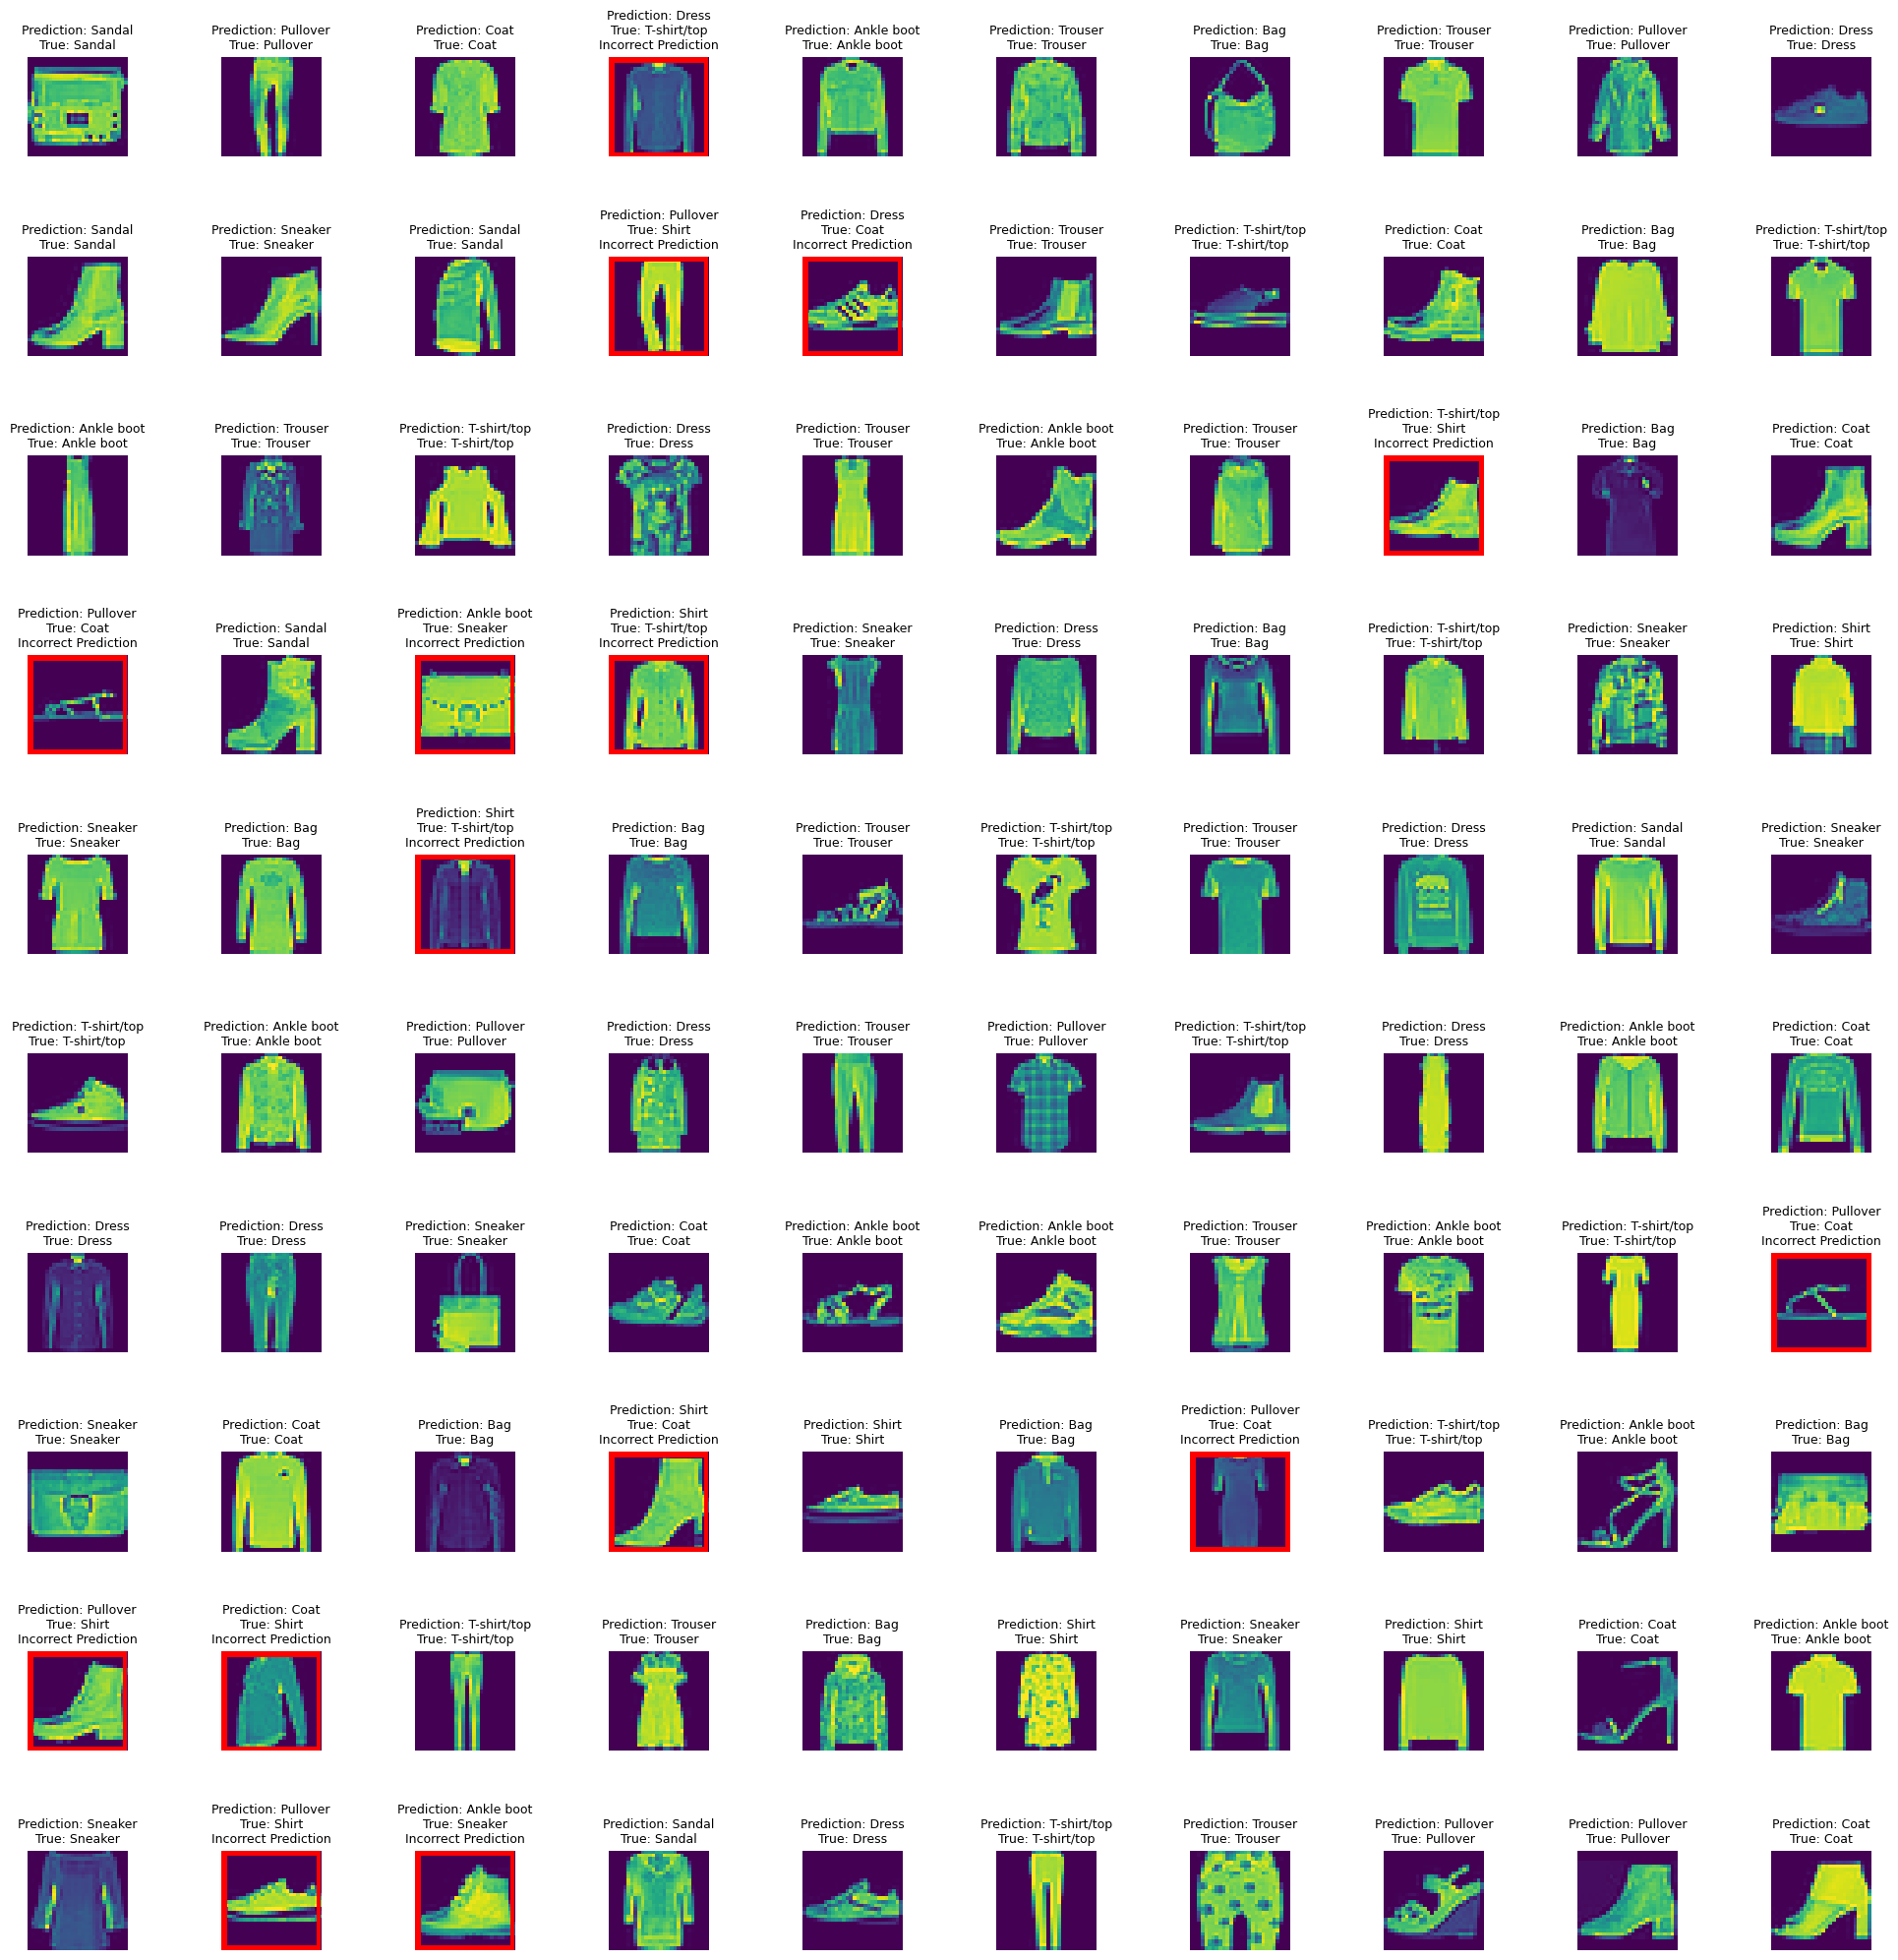

In [29]:
import matplotlib.patches as patches

# Define the grid size for display
W_grid = 10
L_grid = 10

# Create a grid of subplots
fig, axes = plt.subplots(L_grid, W_grid, figsize=(25,25))
axes = axes.ravel() # Flatten the 10x10 grid into 100 elements to easily loop through

# Get the total number of testing images
n_testing = len(test_images)


# Iterate over the axes to plot individual images and titles
for i in np.arange(0,L_grid*W_grid):
    index = np.random.randint(0, n_testing) # Randomly pick an index from the testing set
    axes[i].imshow(train_images[index]) # Display image at that index
    
    title = f"Prediction: {label_names[predicted_classes[index]]}\nTrue: {label_names[test_labels[index]]}"
    
    if predicted_classes[index] != test_labels[index]:
        title += "\nIncorrect Prediction"
        # Draw a rectangle around the subplot
        rect = patches.Rectangle((0,0), 27, 27, linewidth=5, edgecolor='red', facecolor='none')
        axes[i].add_patch(rect)
        
    axes[i].set_title(title, fontsize=9)
    axes[i].axis('off') # Turn off the axis

# Adjust the spacing between the plots
plt.subplots_adjust(hspace=1)
    

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compute the overall weighted accuracy
overall_accuracy = accuracy_score(test_labels, predicted_classes)
print(f'Overall Accuracy: {overall_accuracy:.2f}')

# Compute the overall weighted precision
overall_precision = precision_score(test_labels, predicted_classes, average='weighted')
print(f'Overall Precision: {overall_precision:.2f}')


# Compute the overall recall
overall_recall = recall_score(test_labels, predicted_classes, average='weighted')
print(f'Overall Recall: {overall_recall:.2f}')

# Compute the overall F1-score
overall_f1 = f1_score(test_labels, predicted_classes, average='weighted')
print(f'Overall F1-score: {overall_f1:.2f}')

Overall Accuracy: 0.89
Overall Precision: 0.89
Overall Recall: 0.89
Overall F1-score: 0.89


<Axes: >

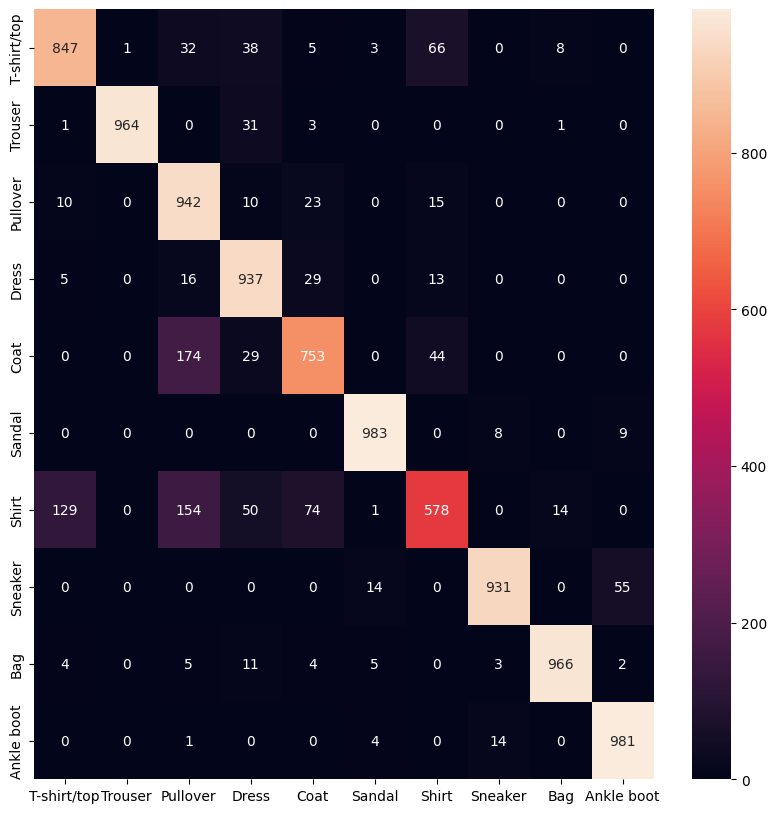

In [31]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for the test labels and predicted classes
cm = confusion_matrix(test_labels, predicted_classes)


plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, xticklabels=label_names.values(), yticklabels=label_names.values(), fmt='d')


In [32]:
from sklearn.metrics import classification_report

# Compute precision, recall, F1-score, and support
cr = classification_report(test_labels, predicted_classes, target_names=list(label_names.values()))

print(cr)

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.85      0.85      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.71      0.94      0.81      1000
       Dress       0.85      0.94      0.89      1000
        Coat       0.85      0.75      0.80      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.81      0.58      0.67      1000
     Sneaker       0.97      0.93      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.94      0.98      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# STEP 6: SAVING THE MODEL

In [33]:
# Import the OS module to interact with the operating system
import os

# Define the directory to save the trained model by joining the current working directory with 'saved_trained_models'
directory = os.path.join(os.getcwd(), 'saved_trained_models')

# If the directory does not exist, create it
if not os.path.isdir(directory):
    os.makedirs(directory)

    
# Define the full path of the model file by joining the directory path with the model filename
model_path = os.path.join(directory, 'keras_fashionMNSIT_trained_model.h5')

# Save the trained model to the specified file path in HDF5 format
cnn_model.save(model_path)


c:\users\davon w williams\appdata\local\programs\python\python38\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [34]:

# Define the directory to save the trained model by joining the current working directory with 'saved_trained_models'
directory1 = os.path.join(os.getcwd(), 'saved_trained_models')

# If the directory does not exist, create it
if not os.path.isdir(directory1):
    os.makedirs(directory1)
    
# Define the full path of the model file by joining the directory path with the model filename
model_path1 = os.path.join(directory1, 'keras_fashionMNSIT_trained_model.keras')

# Save the trained model to the specified file path in Keres format
cnn_model.save(model_path1)